In [192]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import classification_report, mean_squared_error

In [193]:

# 1) Load preprocessed frame‐level features (wide) and play outcomes
features = pd.read_csv("../data/wide_features.csv")
outcomes = pd.read_csv("../data/play_outcomes.csv")
features = features.rename(columns={"gameId":"game_id","playId":"play_id","frameId":"frame_id"})


In [194]:

# Merge outcomes onto features
test_df = features.merge(outcomes[["game_id", "play_id", "targeted_receiver_nflId"]], on=["game_id", "play_id"])

# Get receiver index (0–5 for players 5–10)
def get_receiver_index(row):
    for i in range(6, 11):  # player_5 to player_10
        if row[f"player{i}_nflId"] == row["targeted_receiver_nflId"]:
            return i - 6 
    return -1  # not found

test_df["target_receiver_index"] = test_df.apply(get_receiver_index, axis=1)
features = test_df[test_df["target_receiver_index"] != -1]  # Keep only valid rows
test_df[[ "player6_nflId", "player7_nflId", "player8_nflId", "player9_nflId", "player10_nflId", "targeted_receiver_nflId", "target_receiver_index"]]
# test_df[["player5_position", "player6_position", "player7_position", "player8_position", "player9_position", "player10_position", "targeted_receiver_nflId", "target_receiver_index"]]
# test_df[test_df["target_receiver_index"] == -1].drop_duplicates(subset=["game_id", "play_id"]) #these are plays with no receiver


,player6_nflId,player7_nflId,player8_nflId,player9_nflId,player10_nflId,targeted_receiver_nflId,target_receiver_index
0,47857.0,47879.0,42489.0,44985.0,52536.0,42489.0,2
1,47857.0,47879.0,42489.0,44985.0,52536.0,42489.0,2
2,47857.0,47879.0,42489.0,44985.0,52536.0,42489.0,2
3,47857.0,47879.0,42489.0,44985.0,52536.0,42489.0,2
4,47857.0,47879.0,42489.0,44985.0,52536.0,42489.0,2
...,...,...,...,...,...,...,...
30876,53464.0,52526.0,46109.0,52423.0,52454.0,53464.0,0
30877,53464.0,52526.0,46109.0,52423.0,52454.0,53464.0,0
30878,53464.0,52526.0,46109.0,52423.0,52454.0,53464.0,0
30879,53464.0,52526.0,46109.0,52423.0,52454.0,53464.0,0


In [195]:
# plt.hist(test_df[test_df["target_receiver_index"] < 6]["target_receiver_index"])


In [196]:
def add_target_onehot(X, target_idx_col):
    target_onehot = np.zeros((len(X), 5))
    target_indices = X[target_idx_col].values.astype(int)
    for i, idx in enumerate(target_indices):
        target_onehot[i, idx] = 1
    return np.concatenate([X.drop(columns=[target_idx_col]).values, target_onehot], axis=1)

add_target_onehot(test_df, "target_receiver_index")

array([[2022090800, 56, 146, ..., 1.0, 0.0, 0.0],
       [2022090800, 56, 147, ..., 1.0, 0.0, 0.0],
       [2022090800, 56, 148, ..., 1.0, 0.0, 0.0],
       ...,
       [2022091200, 3826, 117, ..., 0.0, 0.0, 0.0],
       [2022091200, 3826, 118, ..., 0.0, 0.0, 0.0],
       [2022091200, 3826, 119, ..., 0.0, 0.0, 0.0]], dtype=object)

In [229]:
for i in features.columns:
  print(i)

game_id
play_id
frame_id
player0_nflId
player0_displayName_x
player0_x
player0_y
player0_s
player0_a
player0_dis
player0_o
player0_dir
player0_position
player0_displayName_y
player1_nflId
player1_displayName_x
player1_x
player1_y
player1_s
player1_a
player1_dis
player1_o
player1_dir
player1_position
player1_displayName_y
player2_nflId
player2_displayName_x
player2_x
player2_y
player2_s
player2_a
player2_dis
player2_o
player2_dir
player2_position
player2_displayName_y
player3_nflId
player3_displayName_x
player3_x
player3_y
player3_s
player3_a
player3_dis
player3_o
player3_dir
player3_position
player3_displayName_y
player4_nflId
player4_displayName_x
player4_x
player4_y
player4_s
player4_a
player4_dis
player4_o
player4_dir
player4_position
player4_displayName_y
player5_nflId
player5_displayName_x
player5_x
player5_y
player5_s
player5_a
player5_dis
player5_o
player5_dir
player5_position
player5_displayName_y
player6_nflId
player6_displayName_x
player6_x
player6_y
player6_s
player6_a
playe

In [197]:
# Merge end_frame into features
features = features.merge(
    outcomes[["game_id", "play_id", "end_frame"]],
    on=["game_id", "play_id"],
    how="left"
)

# Filter to only the final frame of each play
last_frame_features = features[features["frame_id"] == features["end_frame"]].copy()

# Optionally, drop 'end_frame' if not needed anymore
last_frame_features.drop(columns=["end_frame"], inplace=True)
features = last_frame_features


In [198]:
outcomes

,game_id,play_id,start_frame,end_frame,play_type,down,yards_to_go,yards_gained,pass_result,targeted_receiver_nflId,time_to_throw
0,2022091104,3662,106,121,I,3,12,0,I,53439.0,15.0
1,2022091112,1674,151,196,IN,1,10,0,IN,37139.0,45.0
2,2022091111,923,87,122,C,1,10,42,C,40024.0,35.0
3,2022091109,3544,54,69,C,2,7,-1,C,44852.0,15.0
4,2022091109,2502,75,104,C,2,3,3,C,52733.0,29.0
...,...,...,...,...,...,...,...,...,...,...,...
1073,2022090800,212,104,153,C,2,9,8,C,52494.0,49.0
1074,2022091110,291,122,144,C,2,9,9,C,40011.0,22.0
1075,2022091104,3956,70,100,C,1,10,5,C,53541.0,30.0
1076,2022091112,275,128,144,C,4,1,5,C,52430.0,16.0


In [199]:

# features_with_outcomes = features.merge(outcomes[['game_id', 'play_id', 'start_frame', 'end_frame']], 
#                                         on=['game_id', 'play_id'], how='left')

# # Step 2: Check if frame_ids in features are within the start_frame and end_frame
# misaligned = features_with_outcomes[
#     (features_with_outcomes['frame_id'] < features_with_outcomes['start_frame']) |
#     (features_with_outcomes['frame_id'] > features_with_outcomes['end_frame'])
# ]

# if not misaligned.empty:
#     print(f"Warning: Found {len(misaligned)} misaligned frames")
# else:
#     print("All frames in features are within the start and end frames of their respective plays.")


In [200]:

# Step 3: Merge all outcome columns into features
features = features.merge(outcomes, on=['game_id', 'play_id'], how='left')



# Step 5: Create new feature: frames from snap
features['frames_from_snap'] = features['frame_id'] - features['start_frame']

In [201]:
# 3) Build X, y for two tasks:
#   a) Classification: pass_result (C vs I vs IN)
#   b) Regression: yards_gained

# a) Classification target
# Drop columns that start with 'name_' or 'jersey_', and also 'start_frame' and 'end_frame'
cols_to_drop = [col for col in features.columns 
                if col.endswith('Name_x') or col.endswith('nflId') or col.endswith('displayName_y') or col.endswith('_position')
                or col in ['start_frame', 'end_frame', "game_id","play_id","frame_id","yards_gained","play_type","pass_result","player22_nflId","targeted_receiver","time_to_throw", "player22_o",	"player22_dir",	"player22_position",	"player22_displayName_y"]]


clf_df = features.dropna(subset=["pass_result"]).copy()
X_clf = clf_df.drop(columns=cols_to_drop)
y_clf = clf_df["pass_result"]
le = LabelEncoder()
y_clf_enc = le.fit_transform(y_clf)  # e.g. ['C','I','IN']→[0,1,2]

# b) Regression target
reg_df = features.copy()
X_reg = reg_df.drop(columns=cols_to_drop)
y_reg = reg_df["yards_gained"]

In [202]:
X_clf

,player0_x,player0_y,player0_s,player0_a,player0_dis,player0_o,player0_dir,player1_x,player1_y,player1_s,...,player22_y,player22_s,player22_a,player22_dis,targeted_receiver_nflId_x,target_receiver_index,down,yards_to_go,targeted_receiver_nflId_y,frames_from_snap
0,90.91,29.90,0.70,0.59,0.06,326.48,300.54,87.98,28.65,1.23,...,30.340000,0.98,1.25,0.09,42489.0,2,1,10,42489.0,21
1,74.41,31.23,3.42,1.24,0.34,332.82,46.32,70.64,30.45,3.04,...,31.790001,3.56,1.68,0.35,47857.0,0,2,3,47857.0,29
2,63.68,24.15,0.56,0.77,0.06,322.27,30.30,60.25,24.50,2.76,...,24.629999,2.83,3.39,0.26,42489.0,2,2,8,42489.0,19
3,49.98,41.65,7.60,1.54,0.76,302.26,338.79,43.81,28.62,2.61,...,42.209999,21.83,0.21,1.82,52494.0,0,2,9,52494.0,49
4,43.04,37.09,6.11,1.43,0.62,309.51,1.74,37.20,34.47,3.80,...,37.270000,4.72,3.28,0.38,52536.0,4,3,1,52536.0,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,91.11,23.91,1.82,0.65,0.18,346.46,31.47,87.03,22.69,2.10,...,24.559999,3.36,2.52,0.32,52526.0,1,3,5,52526.0,30
1040,83.81,29.54,0.33,0.72,0.03,323.82,9.90,80.80,31.59,0.66,...,30.090000,1.56,3.03,0.15,52526.0,1,1,10,52526.0,19
1041,78.14,29.34,0.28,0.97,0.02,290.00,320.59,74.77,29.99,0.94,...,31.040001,17.34,0.09,2.09,53464.0,0,3,2,53464.0,27
1042,67.78,29.27,0.40,2.24,0.05,281.86,83.67,63.20,30.50,1.71,...,30.570000,4.32,8.43,0.39,53464.0,0,1,10,53464.0,19


In [203]:

# 4) Train/test split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf_enc, test_size=0.2, random_state=42, stratify=y_clf_enc
)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [204]:
# Xc_train.iloc[:, 30:50].dtypes
yc_train.shape


(835,)

In [205]:

# 5) Scale features
scaler_c = StandardScaler().fit(Xc_train)


In [206]:
Xc_train_s = scaler_c.transform(Xc_train)
Xc_test_s  = scaler_c.transform(Xc_test)

scaler_r = StandardScaler().fit(Xr_train)
Xr_train_s = scaler_r.transform(Xr_train)
Xr_test_s  = scaler_r.transform(Xr_test)

In [207]:
# 6a) Train classifier
clf = MLPClassifier(
    hidden_layer_sizes=(128,64),
    activation="relu",
    solver="adam",
    max_iter=200,
    random_state=42
)
clf.fit(Xc_train_s, yc_train)

# 6b) Train regressor
reg = MLPRegressor(
    hidden_layer_sizes=(128,64),
    activation="relu",
    solver="adam",
    max_iter=200,
    random_state=42
)
reg.fit(Xr_train_s, yr_train)

MLPRegressor(hidden_layer_sizes=(128, 64), random_state=42)

In [208]:








# 7a) Evaluate classifier
yc_pred = clf.predict(Xc_test_s)
print("=== Classification Report (pass_result) ===")
print(classification_report(yc_test, yc_pred, target_names=le.classes_))

# 7b) Evaluate regressor
yr_pred = reg.predict(Xr_test_s)
mse = mean_squared_error(yr_test, yr_pred)
print(f"=== Regression MSE (yards_gained): {mse:.2f} ===")


=== Classification Report (pass_result) ===
              precision    recall  f1-score   support

           C       0.69      0.76      0.72       139
           I       0.35      0.31      0.33        65
          IN       0.00      0.00      0.00         5

    accuracy                           0.60       209
   macro avg       0.35      0.35      0.35       209
weighted avg       0.57      0.60      0.58       209

=== Regression MSE (yards_gained): 131.07 ===


c:\Users\jesse\anaconda3\envs\nflenv\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\jesse\anaconda3\envs\nflenv\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\jesse\anaconda3\envs\nflenv\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


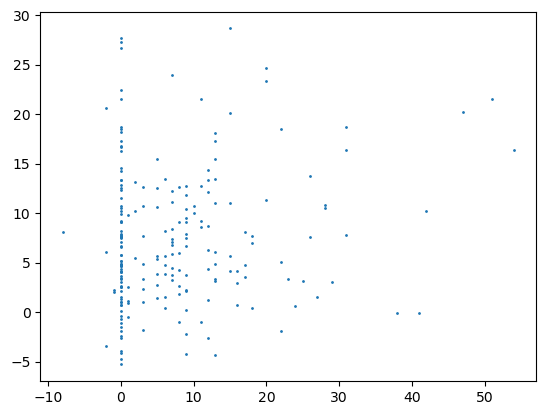

In [209]:
import matplotlib.pyplot as plt
plt.scatter(yr_test, yr_pred,s=1)

(array([152.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  57.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

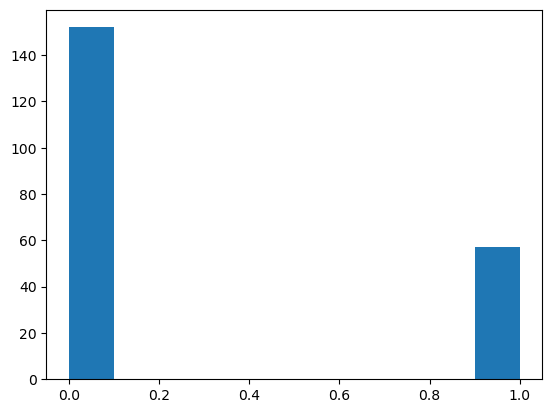

In [210]:
plt.hist(yc_pred)

In [211]:
import torch
import torch.nn as nn
import torch.optim as optim

import torch
import torch.nn as nn
import torch.optim as optim

class CustomNet(nn.Module):
    def __init__(self, input_dim, num_classes=5, dropout_rate=0.4):
        super(CustomNet, self).__init__()

        # Input -> 230
        self.input_layer = nn.Linear(input_dim, 230)
        self.bn0 = nn.BatchNorm1d(230)

        # 230 -> 256
        self.hidden_layer1 = nn.Linear(230, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(dropout_rate)

        # 256 -> 128
        self.hidden_layer2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(dropout_rate)

        # Output layers
        self.class_output = nn.Linear(128, num_classes)
        self.reg_output = nn.Linear(128, 1)

        # Activations
        self.act = nn.LeakyReLU()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.bn0(x)
        
        x = self.act(self.hidden_layer1(x))
        x = self.bn1(x)
        x = self.dropout1(x)
        
        x = self.act(self.hidden_layer2(x))
        x = self.bn2(x)
        x = self.dropout2(x)
        
        class_output = self.class_output(x)
        reg_output = self.reg_output(x)

        return class_output, reg_output


model = CustomNet(input_dim=Xc_train.shape[1])
criterion_class = nn.CrossEntropyLoss()
criterion_reg = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)





In [212]:
Xc_train.shape[1]

165

In [213]:
# Assuming you have your training data in Xc_train, yc_train, Xr_train, yr_train
Xc_train_np = Xc_train.to_numpy() if hasattr(Xc_train, "to_numpy") else Xc_train
yc_train_np = yc_train.to_numpy() if hasattr(yc_train, "to_numpy") else yc_train
yr_train_np = yr_train.to_numpy() if hasattr(yr_train, "to_numpy") else yr_train

# Convert to torch tensors
X_train_tensor = torch.tensor(Xc_train_np, dtype=torch.float32)
yc_train_tensor = torch.tensor(yc_train_np, dtype=torch.long)  # For classification (long type)
yr_train_tensor = torch.tensor(yr_train_np, dtype=torch.float32).unsqueeze(1)  # For regression (float)

# Create DataLoader
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, yc_train_tensor, yr_train_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# Training loop
for epoch in range(20):
    model.train()
    total_loss = 0
    for X_batch, y_class, y_reg in train_loader:
        optimizer.zero_grad()
        
        # Forward pass
        class_pred, reg_pred = model(X_batch)
        
        # Compute losses
        loss_class = criterion_class(class_pred, y_class)
        loss_reg = criterion_reg(reg_pred, y_reg)
        
        # Total loss (you can weight the losses differently if needed)
        total_loss = loss_class + loss_reg
        
        # Backward pass and optimization
        total_loss.backward()
        optimizer.step()
        
    print(f"Epoch {epoch + 1}/{20}, Loss: {total_loss.item():.4f}")


Epoch 1/20, Loss: 37.3051
Epoch 2/20, Loss: 12.7680
Epoch 3/20, Loss: 73.7758
Epoch 4/20, Loss: 162.6928
Epoch 5/20, Loss: 87.1901
Epoch 6/20, Loss: 24.4323
Epoch 7/20, Loss: 227.8146
Epoch 8/20, Loss: 3.9112
Epoch 9/20, Loss: 145.0675
Epoch 10/20, Loss: 245.3221
Epoch 11/20, Loss: 85.7551
Epoch 12/20, Loss: 3.0906
Epoch 13/20, Loss: 73.9269
Epoch 14/20, Loss: 30.4032
Epoch 15/20, Loss: 9.2259
Epoch 16/20, Loss: 35.3609
Epoch 17/20, Loss: 21.5684
Epoch 18/20, Loss: 30.4021
Epoch 19/20, Loss: 14.5027
Epoch 20/20, Loss: 7.6404


In [223]:
# Convert test sets to NumPy arrays if needed
Xc_test_np = Xc_test.to_numpy() if hasattr(Xc_test, "to_numpy") else Xc_test
yc_test_np = yc_test.to_numpy() if hasattr(yc_test, "to_numpy") else yc_test
yr_test_np = yr_test.to_numpy() if hasattr(yr_test, "to_numpy") else yr_test

# Convert to tensors
X_test_tensor = torch.tensor(Xc_test_np, dtype=torch.float32)
yc_test_tensor = torch.tensor(yc_test_np, dtype=torch.long)
yr_test_tensor = torch.tensor(yr_test_np, dtype=torch.float32).unsqueeze(1)


In [224]:
Xc_test_np = X_clf.to_numpy()
yc_test_np = y_clf_enc
yr_test_np = reg_df["yards_gained"].to_numpy()

print(Xc_test_np.shape)
print(yc_test_np.shape)
print(yr_test_np.shape)


(209, 165)
(209,)
(209,)


In [216]:
# Convert to tensors
X_test_tensor = torch.tensor(Xc_test_np, dtype=torch.float32)
yc_test_tensor = torch.tensor(yc_test_np, dtype=torch.long)
yr_test_tensor = torch.tensor(yr_test_np, dtype=torch.float32).unsqueeze(1)

In [217]:

model.eval()
with torch.no_grad():
    class_logits, reg_preds = model(X_test_tensor)
    
    # Get predicted classes
    class_preds = torch.argmax(class_logits, dim=1)
    probs = torch.softmax(class_logits, dim=1).numpy()

    # For accuracy
    correct = (class_preds == yc_test_tensor).sum().item()
    total = yc_test_tensor.size(0)
    accuracy = correct / total

    # For regression error (RMSE)
    mse = nn.MSELoss()(reg_preds, yr_test_tensor).item()
    rmse = mse ** 0.5
prob_complete = probs[:, 0]  # Probabilities for class "complete"
true_complete = (yc_test_np == 0).astype(int)  # True labels for "complete" class

print(f"Classification Accuracy: {accuracy:.4f}")
print(f"Regression RMSE: {rmse:.2f} yards")


Classification Accuracy: 0.6025
Regression RMSE: 11.67 yards


(array([ 28.,  69., 103., 150., 167., 210., 158., 106.,  43.,  10.]),
 array([0.11692328, 0.18408117, 0.25123906, 0.31839696, 0.38555485,
        0.45271274, 0.51987064, 0.58702856, 0.65418643, 0.72134435,
        0.78850222]),
 <BarContainer object of 10 artists>)

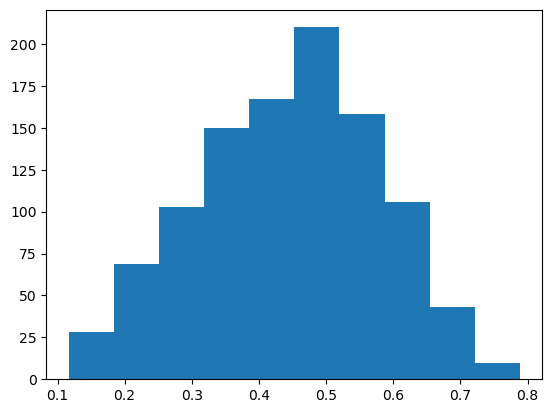

In [218]:
plt.hist(probs[:, 0])

0.44503298

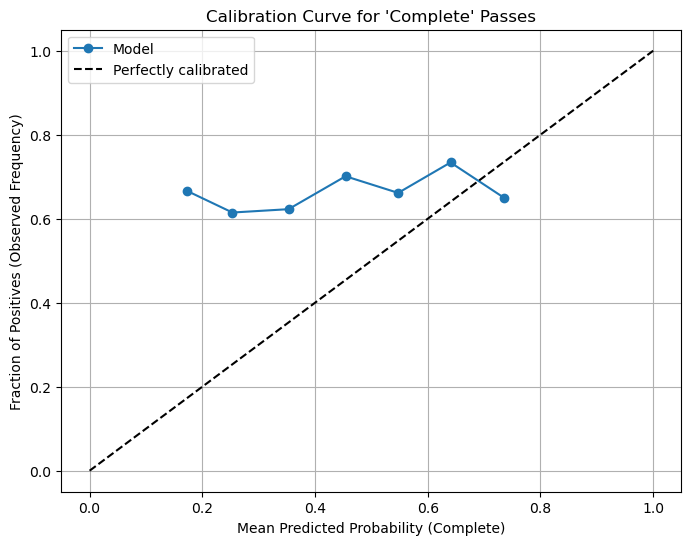

In [219]:
from sklearn.calibration import calibration_curve
# Compute calibration curve (reliability curve)
fraction_of_positives, mean_predicted_value = calibration_curve(true_complete, prob_complete, n_bins=10, strategy='uniform')

# Plot
plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "o-", label="Model")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Mean Predicted Probability (Complete)")
plt.ylabel("Fraction of Positives (Observed Frequency)")
plt.title("Calibration Curve for 'Complete' Passes")
plt.legend()
plt.grid(True)
plt.show()


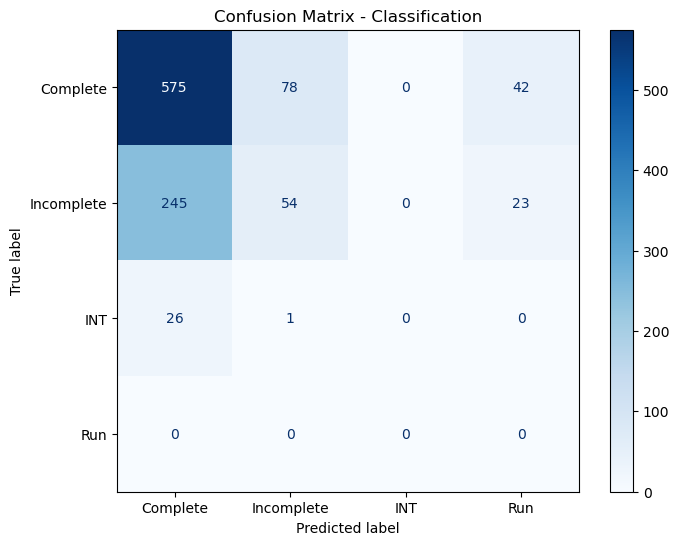

In [221]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix
cm = confusion_matrix(yc_test_np, class_preds.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Complete", "Incomplete", "INT", "Run",])# "Sack"

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Classification")
plt.show()


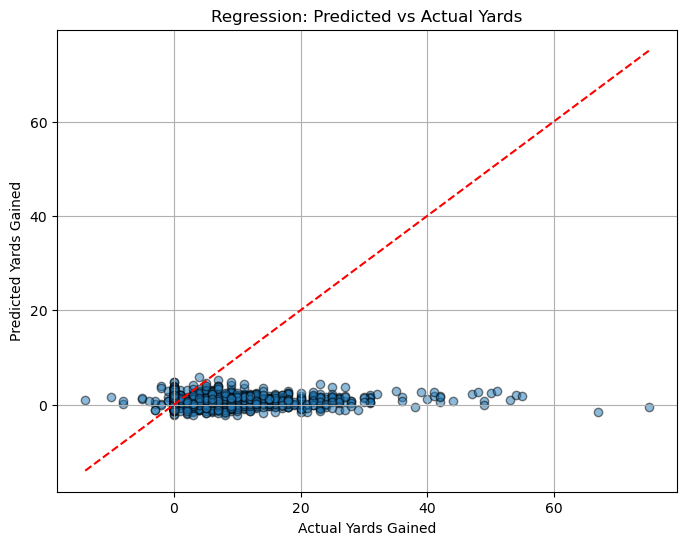

In [222]:
plt.figure(figsize=(8, 6))
plt.scatter(yr_test_np, reg_preds.numpy(), alpha=0.5, edgecolors='k')
plt.plot([min(yr_test_np), max(yr_test_np)], [min(yr_test_np), max(yr_test_np)], 'r--')  # Ideal line
plt.xlabel("Actual Yards Gained")
plt.ylabel("Predicted Yards Gained")
plt.title("Regression: Predicted vs Actual Yards")
plt.grid(True)
plt.show()
